Predice si un paciente tiene riesgo de fallo cardíaco, clasificado como 1, o está sano, clasificado como 0, basándose en variables numéricas continuas como la edad y el colesterol

**Bloque 1: Importaciones y Conexión**

In [ ]:
# PASO 1: Importar librerías
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
# Modulo de optimización de scipy (exigido por el ingeniero)
from scipy import optimize
%matplotlib inline

# Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Bloque 2: Cargar Datos y Preparar X e y

In [ ]:
# PASO 2: Cargar y limpiar datos
ruta = '/content/drive/MyDrive/Inteligencia Artificial 1 - Kevin/Ejercicio en clases/heart.csv'
df = pd.read_csv(ruta)

# Extraemos solo números y quitamos nulos
df_numerico = df.select_dtypes(include=[np.number]).dropna()

# Separamos: y = HeartDisease (0 o 1), X = Todo lo demás
y = df_numerico['HeartDisease'].values
columnas_x = [col for col in df_numerico.columns if col != 'HeartDisease']
X = df_numerico[columnas_x].values

m, n = X.shape

# Agregar la columna de unos (término de intercepción) a X
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(f"Total de pacientes (m): {m}")
print(f"Total de variables (n): {n}")
print("¡Matriz X configurada y lista!")

#print(X)
#print(y)

Total de pacientes (m): 918
Total de variables (n): 6
¡Matriz X configurada y lista!


Bloque 3: La Función Sigmoide

In [ ]:
# PASO 3: Función Sigmoidea
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba sigmoid(0) debe dar 0.5
print('Prueba de sigmoid(0):', sigmoid(0))

Prueba de sigmoid(0): 0.5


Bloque 4: Función de Costo y Gradiente

In [ ]:
# PASO 4: Costo y Gradiente
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size

    h = sigmoid(X.dot(theta.T))
    # Ecuación de costo con logaritmos
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    # Gradiente
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

Bloque 5: Optimización Inteligente (SciPy)

In [ ]:
# PASO 5: Parámetros de aprendizaje usando scipy.optimize
# Inicializamos theta en ceros
initial_theta = np.zeros(X.shape[1])

# Opciones para el algoritmo
options= {'maxiter': 1000}

# Ejecutamos el optimizador TNC
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta_opt = res.x

print('Costo optimizado encontrado: {:.3f}'.format(cost))
print('Thetas calculados (primeros 5):', theta_opt[:5])

Costo optimizado encontrado: 0.486
Thetas calculados (primeros 5): [ 3.13867663e+00  1.02813014e-02  2.31967836e-03 -3.76740257e-03
  1.22490066e+00]


/tmp/ipykernel_942/141816517.py:9: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


Bloque 6: Evaluación (Predecir un paciente)

In [ ]:
# PASO 6: Inferencia (Evaluación de la regresión logística)
def predict(theta, X):
    # Calcula predicciones usando el umbral en 0.5
    m = X.shape[0]
    p = np.zeros(m)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Inventamos un paciente tomando los promedios de todos
paciente_inventado = np.mean(X, axis=0)

# Calculamos su probabilidad matemática
probabilidad = sigmoid(np.dot(paciente_inventado, theta_opt))
prediccion = predict(theta_opt, np.array([paciente_inventado]))

print(f"Probabilidad de que este paciente tenga fallo cardíaco: {probabilidad:.3f}")
print(f"Diagnóstico final de la IA (1=Riesgo, 0=Sano): {prediccion[0]}")

Probabilidad de que este paciente tenga fallo cardíaco: 0.594
Diagnóstico final de la IA (1=Riesgo, 0=Sano): 1.0


El dataset tiene 6 variables predictoras (n=6), no podemos dibujar en 6 dimensiones. Así que tomaremos las dos primeras columnas numéricas (que usualmente son Edad y Presión/Colesterol) para hacer la gráfica 2D, igual que tu ingeniero hizo con las calificaciones del "Examen 1" y "Examen 2".

Generando gráfica bidimensional...


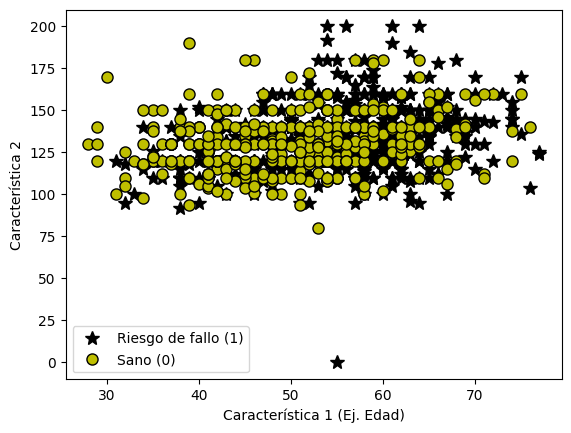

In [ ]:
# PASO EXTRA: Visualizar los datos en 2D
# Se completa el código en plotData para mostrar los ejemplos positivos y negativos con diferentes marcadores
def plotData(X, y):
    # Crea una nueva figura
    fig = pyplot.figure()

    # Encuentra los índices de ejemplos positivos (Riesgo) y negativos (Sanos)
    pos = y == 1
    neg = y == 0

    # Grafica los puntos: * para los positivos y o para los negativos
    # Usamos X[:, 1] y X[:, 2] porque la columna 0 ahora son los "unos" de intercepción
    pyplot.plot(X[pos, 1], X[pos, 2], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 1], X[neg, 2], 'ko', mfc='y', ms=8, mec='k', mew=1)

print("Generando gráfica bidimensional...")
plotData(X, y)

# Adiciona etiquetas para los ejes
pyplot.xlabel('Característica 1 (Ej. Edad)')
pyplot.ylabel('Característica 2')
pyplot.legend(['Riesgo de fallo (1)', 'Sano (0)'])
pyplot.show()